<a href="https://colab.research.google.com/github/charithak2003/Data-Science/blob/main/SalesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/train.csv')
display(df.head())
display(df.shape)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


(9800, 18)

In [ ]:
print("Available numerical columns for prediction:")
print(df.select_dtypes(include=['number']).columns.tolist())

Available numerical columns for prediction:
['Row ID', 'Postal Code', 'Sales']


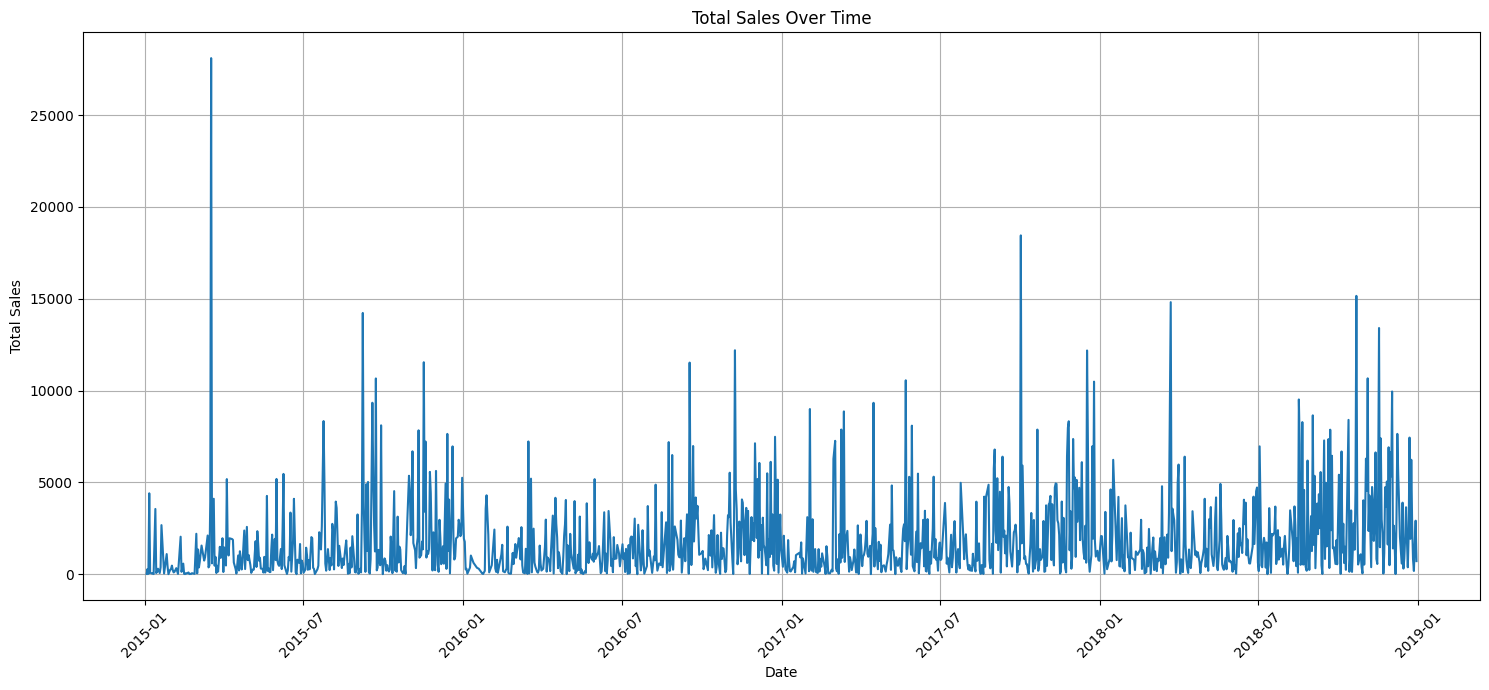

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(x='Order Date', y='Sales', data=daily_sales)
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation of numerical columns with 'Sales'
sales_correlations = numerical_df.corr()['Sales'].sort_values(ascending=False)

print("Correlation of numerical columns with 'Sales':")
display(sales_correlations)

Correlation of numerical columns with 'Sales':


,Sales
Sales,1.000000
Row ID,0.001151
Postal Code,-0.024067


### Dropping irrelevant columns

Dropping 'Order ID' and 'Row ID' columns as they are not useful for prediction and correlation analysis.

In [ ]:
df = df.drop(columns=['Order ID', 'Row ID'])
display(df.head())

,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Ordinal Encoding for 'Ship Mode'

Using `LabelEncoder` to convert the categorical 'Ship Mode' column into numerical labels. This is a common preprocessing step for machine learning models that require numerical input.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Ship Mode'] = le.fit_transform(df['Ship Mode'])
display(df.head())

,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,2017-11-08,11/11/2017,2,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2017-11-08,11/11/2017,2,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,2017-06-12,16/06/2017,2,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,2016-10-11,18/10/2016,3,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,2016-10-11,18/10/2016,3,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### One-Hot Encoding for Categorical Features

Applying one-hot encoding to 'Segment', 'Country', 'City', 'State', 'Region', 'Category', and 'Sub-Category' columns using `pd.get_dummies`. This expands each categorical column into multiple binary columns, one for each category, which is essential for models that cannot directly handle categorical input.

In [ ]:
categorical_columns = ['Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category']
df = pd.get_dummies(df, columns=categorical_columns, dtype=int)
display(df.head())
print(f"DataFrame shape after one-hot encoding: {df.shape}")

,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Postal Code,Product ID,Product Name,Sales,Segment_Consumer,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,2017-11-08,11/11/2017,2,CG-12520,Claire Gute,42420.0,FUR-BO-10001798,Bush Somerset Collection Bookcase,261.9600,1,...,0,0,0,0,0,0,0,0,0,0
1,2017-11-08,11/11/2017,2,CG-12520,Claire Gute,42420.0,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,1,...,0,0,0,0,0,0,0,0,0,0
2,2017-06-12,16/06/2017,2,DV-13045,Darrin Van Huff,90036.0,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters b...,14.6200,0,...,0,0,0,1,0,0,0,0,0,0
3,2016-10-11,18/10/2016,3,SO-20335,Sean O'Donnell,33311.0,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,957.5775,1,...,0,0,0,0,0,0,0,0,0,1
4,2016-10-11,18/10/2016,3,SO-20335,Sean O'Donnell,33311.0,OFF-ST-10000760,Eldon Fold 'N Roll Cart System,22.3680,1,...,0,0,0,0,0,0,0,1,0,0


DataFrame shape after one-hot encoding: (9800, 615)


### Feature Engineering for Date Columns

Extracting numerical features such as year, month, day, and day of week from 'Order Date' and 'Ship Date' to make them usable for machine learning models. This enriches the dataset with time-based information.

In [ ]:
# Ensure date columns are in datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
# Assuming 'Ship Date' might be in 'DD/MM/YYYY' format if not already converted
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce', format='%d/%m/%Y')

# Extract numerical features from 'Order Date'
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Day'] = df['Order Date'].dt.day
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek

# Extract numerical features from 'Ship Date'
df['Ship_Year'] = df['Ship Date'].dt.year
df['Ship_Month'] = df['Ship Date'].dt.month
df['Ship_Day'] = df['Ship Date'].dt.day
df['Ship_DayOfWeek'] = df['Ship Date'].dt.dayofweek

# Drop original date columns as features have been extracted
df = df.drop(columns=['Order Date', 'Ship Date'])

# Drop identifier columns
df = df.drop(columns=['Customer ID', 'Customer Name', 'Product ID', 'Product Name'])

display(df.head())
print(f"DataFrame shape after processing dates and dropping identifiers: {df.shape}")

,Ship Mode,Postal Code,Sales,Segment_Consumer,Segment_Corporate,Segment_Home Office,Country_United States,City_Aberdeen,City_Abilene,City_Akron,...,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek
0,2,42420.0,261.9600,1,0,0,1,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
1,2,42420.0,731.9400,1,0,0,1,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
2,2,90036.0,14.6200,0,1,0,1,0,0,0,...,0,0,2017,6,12,0,2017,6,16,4
3,3,33311.0,957.5775,1,0,0,1,0,0,0,...,0,1,2016,10,11,1,2016,10,18,1
4,3,33311.0,22.3680,1,0,0,1,0,0,0,...,0,0,2016,10,11,1,2016,10,18,1


DataFrame shape after processing dates and dropping identifiers: (9800, 617)


### Dropping Identifier Columns

Dropping 'Customer ID', 'Customer Name', 'Product ID', and 'Product Name' as these are high-cardinality identifiers that are generally not directly useful for a generic prediction model and can introduce noise or increase dimensionality unnecessarily.

In [ ]:

columns_to_drop = ['Customer ID', 'Customer Name', 'Product ID', 'Product Name']

# Filter out columns that do not exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("Specified identifier columns were not found in the DataFrame (already dropped or never existed).")

display(df.head())
print(f"DataFrame shape after checking for and dropping identifier columns: {df.shape}")

Specified identifier columns were not found in the DataFrame (already dropped or never existed).


,Ship Mode,Postal Code,Sales,Segment_Consumer,Segment_Corporate,Segment_Home Office,Country_United States,City_Aberdeen,City_Abilene,City_Akron,...,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek
0,2,42420.0,261.9600,1,0,0,1,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
1,2,42420.0,731.9400,1,0,0,1,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
2,2,90036.0,14.6200,0,1,0,1,0,0,0,...,0,0,2017,6,12,0,2017,6,16,4
3,3,33311.0,957.5775,1,0,0,1,0,0,0,...,0,1,2016,10,11,1,2016,10,18,1
4,3,33311.0,22.3680,1,0,0,1,0,0,0,...,0,0,2016,10,11,1,2016,10,18,1


DataFrame shape after checking for and dropping identifier columns: (9800, 617)


In [ ]:
print("Re-calculating correlation of all numerical columns with 'Sales' after preprocessing:")

# Select only numerical columns for correlation calculation from the processed DataFrame
numerical_df_processed = df.select_dtypes(include=['number'])

# Calculate the correlation of numerical columns with 'Sales'
sales_correlations_processed = numerical_df_processed.corr()['Sales'].sort_values(ascending=False)

display(sales_correlations_processed)

Re-calculating correlation of all numerical columns with 'Sales' after preprocessing:


,Sales
Sales,1.000000
Sub-Category_Copiers,0.260860
Sub-Category_Machines,0.246028
Category_Technology,0.171555
Sub-Category_Chairs,0.123458
...,...
Sub-Category_Furnishings,-0.069774
Sub-Category_Art,-0.092653
Sub-Category_Paper,-0.110004
Category_Office Supplies,-0.219059


The correlations above indicate the linear relationship between each feature and 'Sales'.

*   **Positive correlations** suggest that as the feature's value increases, 'Sales' tends to increase.
*   **Negative correlations** suggest that as the feature's value increases, 'Sales' tends to decrease.
*   Correlations close to **zero** suggest a weak or no linear relationship.

Keep in mind that correlation only captures linear relationships. For a more comprehensive understanding of feature importance, especially for non-linear relationships, you might consider using methods like:

*   **Feature importance from tree-based models** (e.g., Random Forest, Gradient Boosting).
*   **Permutation importance**.
*   **SHAP (SHapley Additive exPlanations) values**.

In [ ]:
zero_correlation_columns = sales_correlations_processed[sales_correlations_processed == 0.0]

if not zero_correlation_columns.empty:
    print("Columns with exactly zero correlation with 'Sales':")
    display(zero_correlation_columns)
else:
    print("No columns found with exactly zero correlation with 'Sales'.")

No columns found with exactly zero correlation with 'Sales'.


In [ ]:
print("--- Column Information and Null Value Check ---")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"  Data Type: {df[col].dtype}")
    null_count = df[col].isnull().sum()
    if null_count > 0:
        print(f"  Null Values: {null_count}")
        print(f"  Percentage Null: {null_count / len(df) * 100:.2f}%")
    else:
        print("  Null Values: None")

print("\n--- Overall Null Value Summary ---")
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0]
if not null_summary.empty:
    print("Columns with null values:")
    display(null_summary.sort_values(ascending=False))
else:
    print("No columns with null values found in the DataFrame.")

--- Column Information and Null Value Check ---

Column: Ship Mode
  Data Type: int64
  Null Values: None

Column: Postal Code
  Data Type: float64
  Null Values: 11
  Percentage Null: 0.11%

Column: Sales
  Data Type: float64
  Null Values: None

Column: Segment_Consumer
  Data Type: int64
  Null Values: None

Column: Segment_Corporate
  Data Type: int64
  Null Values: None

Column: Segment_Home Office
  Data Type: int64
  Null Values: None

Column: Country_United States
  Data Type: int64
  Null Values: None

Column: City_Aberdeen
  Data Type: int64
  Null Values: None

Column: City_Abilene
  Data Type: int64
  Null Values: None

Column: City_Akron
  Data Type: int64
  Null Values: None

Column: City_Albuquerque
  Data Type: int64
  Null Values: None

Column: City_Alexandria
  Data Type: int64
  Null Values: None

Column: City_Allen
  Data Type: int64
  Null Values: None

Column: City_Allentown
  Data Type: int64
  Null Values: None

Column: City_Altoona
  Data Type: int64
  Null Val

,0
Postal Code,11


In [ ]:
display(null_summary)

,0
Postal Code,11


In [ ]:
if 'Postal Code' in df.columns:
    df = df.drop(columns=['Postal Code'])
    print("Column 'Postal Code' dropped successfully.")
else:
    print("Column 'Postal Code' not found in the DataFrame.")

display(df.head())
print(f"DataFrame shape after dropping 'Postal Code': {df.shape}")

Column 'Postal Code' dropped successfully.


,Ship Mode,Sales,Segment_Consumer,Segment_Corporate,Segment_Home Office,Country_United States,City_Aberdeen,City_Abilene,City_Akron,City_Albuquerque,...,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek
0,2,261.9600,1,0,0,1,0,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
1,2,731.9400,1,0,0,1,0,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
2,2,14.6200,0,1,0,1,0,0,0,0,...,0,0,2017,6,12,0,2017,6,16,4
3,3,957.5775,1,0,0,1,0,0,0,0,...,0,1,2016,10,11,1,2016,10,18,1
4,3,22.3680,1,0,0,1,0,0,0,0,...,0,0,2016,10,11,1,2016,10,18,1


DataFrame shape after dropping 'Postal Code': (9800, 616)


### Distribution of 'Sales'

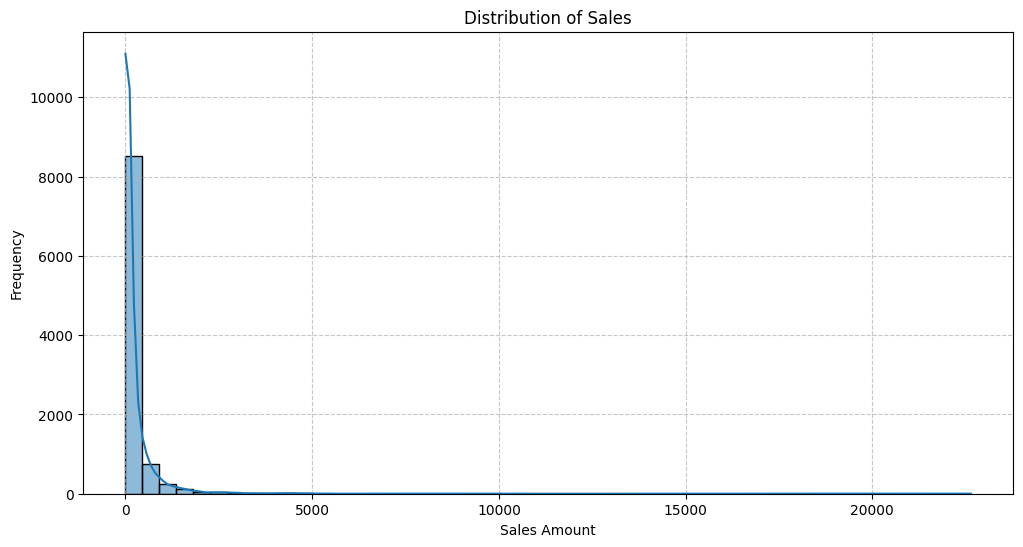

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(df['Sales'], kde=True, bins=50)
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

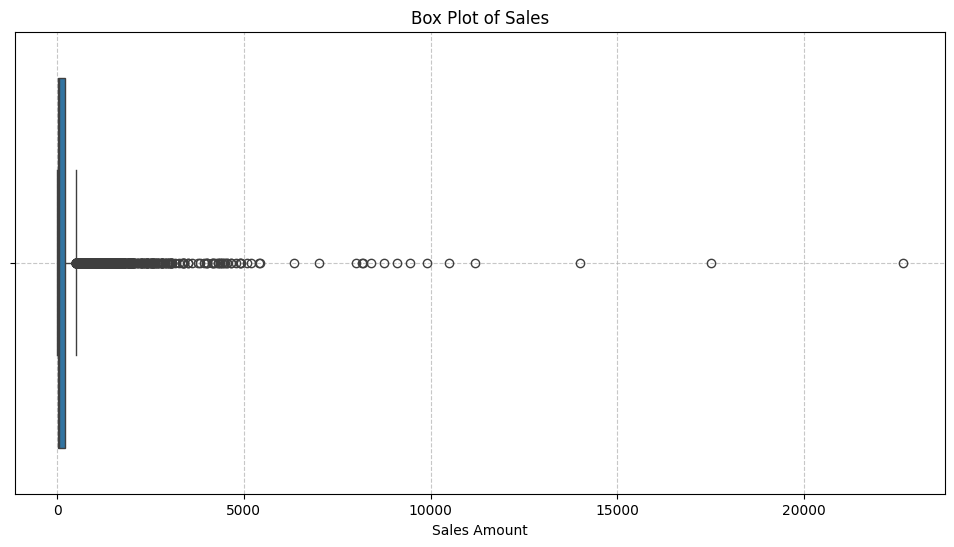

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Sales'])
plt.title('Box Plot of Sales')
plt.xlabel('Sales Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The histogram shows that the 'Sales' distribution is highly right-skewed, meaning most sales are concentrated at lower values, with a long tail extending towards higher sales amounts. The box plot confirms this, showing a large number of outliers on the higher end, which are typical for sales data. We might consider transforming this variable later for modeling purposes, if needed.

### Outlier Detection using IQR Method for 'Sales'

In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print(f"\nNumber of outliers detected: {len(outliers)}")
print("\nFirst 5 outliers (if any):")
display(outliers.head())

Q1 (25th percentile): 17.25
Q3 (75th percentile): 210.61
IQR (Interquartile Range): 193.36
Lower Bound for Outliers: -272.79
Upper Bound for Outliers: 500.64

Number of outliers detected: 1145

First 5 outliers (if any):


,Ship Mode,Sales,Segment_Consumer,Segment_Corporate,Segment_Home Office,Country_United States,City_Aberdeen,City_Abilene,City_Akron,City_Albuquerque,...,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek
1,2,731.9400,1,0,0,1,0,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
3,3,957.5775,1,0,0,1,0,0,0,0,...,0,1,2016,10,11,1,2016,10,18,1
7,3,907.1520,1,0,0,1,0,0,0,0,...,0,0,2015,6,9,1,2015,6,14,6
10,3,1706.1840,1,0,0,1,0,0,0,0,...,0,1,2015,6,9,1,2015,6,14,6
11,3,911.4240,1,0,0,1,0,0,0,0,...,0,0,2015,6,9,1,2015,6,14,6


In [ ]:
df_no_outliers = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing Sales outliers: {df_no_outliers.shape}")
display(df_no_outliers.head())

Original DataFrame shape: (9800, 616)
DataFrame shape after removing Sales outliers: (8655, 616)


,Ship Mode,Sales,Segment_Consumer,Segment_Corporate,Segment_Home Office,Country_United States,City_Aberdeen,City_Abilene,City_Akron,City_Albuquerque,...,Sub-Category_Supplies,Sub-Category_Tables,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek
0,2,261.960,1,0,0,1,0,0,0,0,...,0,0,2017,11,8,2,2017,11,11,5
2,2,14.620,0,1,0,1,0,0,0,0,...,0,0,2017,6,12,0,2017,6,16,4
4,3,22.368,1,0,0,1,0,0,0,0,...,0,0,2016,10,11,1,2016,10,18,1
5,3,48.860,1,0,0,1,0,0,0,0,...,0,0,2015,6,9,1,2015,6,14,6
6,3,7.280,1,0,0,1,0,0,0,0,...,0,0,2015,6,9,1,2015,6,14,6


In [ ]:
df_no_outliers.shape

(8655, 616)

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_no_outliers.drop('Sales', axis=1)
y = df_no_outliers['Sales']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6924, 615)
Shape of X_test: (1731, 615)
Shape of y_train: (6924,)
Shape of y_test: (1731,)


### Re-applying Data Preprocessing for Consistency

It appears that the `X_train` and `X_test` DataFrames created in the previous step still contain non-numeric and un-processed columns, indicating an inconsistency in the application of prior preprocessing steps. To ensure the data is correctly formatted for Linear Regression, we will re-apply the entire preprocessing pipeline from the original dataset.


### Applying Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 69.47
Mean Squared Error (MSE): 9663.20
Root Mean Squared Error (RMSE): 98.30
R-squared (R2): 0.25


### Applying Support Vector Regressor (SVR) Model

Support Vector Machines (SVMs) are powerful models, but they are sensitive to the scale of the features. Therefore, we will first scale the features using `StandardScaler` before training the `SVR` model.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


In [ ]:
# Initialize the SVR model
# Using a linear kernel for initial exploration, can be tuned later
svr_model = SVR(kernel='linear', C=1.0, epsilon=0.1)

# Train the SVR model on the scaled training data
svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")

SVR model trained successfully.


In [ ]:
# Make predictions on the scaled test data
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the SVR model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mse_svr**0.5
r2_svr = r2_score(y_test, y_pred_svr)

print(f"--- SVR Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")

--- SVR Model Evaluation ---
Mean Absolute Error (MAE): 61.22
Mean Squared Error (MSE): 10129.84
Root Mean Squared Error (RMSE): 100.65
R-squared (R2): 0.21
